# Assignment 1: Understanding Generative and Discriminative Models Using MNIST




Course: Generative AI

Name: Keerthi N

Reg No: 2411021240024

Department: Computer Application

University: Alliance University

## Objective

The objective of this assignment is to understand the difference between discriminative and generative models using the MNIST handwritten digit dataset.

In this notebook, only the digits 0 and 1 are considered. Logistic Regression is used as the discriminative model to classify the digits, while an Autoencoder is used as the generative model to learn the patterns of the digit images and reconstruct new examples.

Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

##  Dataset Preparation

The MNIST dataset contains images of handwritten digits from 0 to 9. For this assignment, only the images representing digits 0 and 1 are selected.

The pixel values are normalized between 0 and 1 so that the models can process the images more efficiently.


In [ ]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Select only digits 0 and 1
train_filter = (y_train == 0) | (y_train == 1)
test_filter = (y_test == 0) | (y_test == 1)

x_train = x_train[train_filter]
y_train = y_train[train_filter]

x_test = x_test[test_filter]
y_test = y_test[test_filter]

# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (12665, 28, 28)
Testing images: (2115, 28, 28)


##  Sample Images

The following images show some examples of digits 0 and 1 from the MNIST dataset.

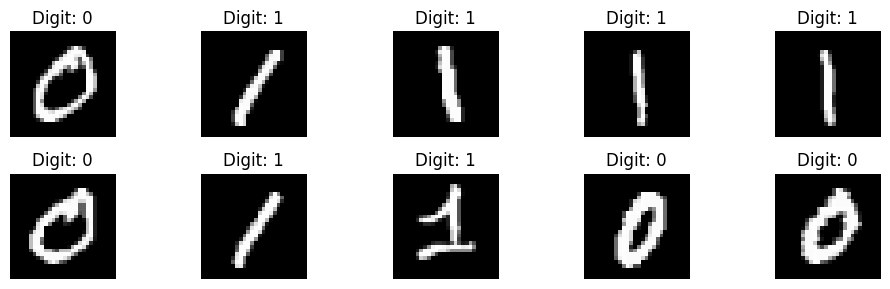

In [ ]:
plt.figure(figsize=(10, 3))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title("Digit: " + str(y_train[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Flatten images from 28x28 into 784 features
x_train_flat = x_train.reshape(len(x_train), -1)
x_test_flat = x_test.reshape(len(x_test), -1)

print("New training shape:", x_train_flat.shape)
print("New testing shape:", x_test_flat.shape)

New training shape: (12665, 784)
New testing shape: (2115, 784)


##  Discriminative Model – Logistic Regression

A discriminative model learns the relationship between the input data and its label.

Here, Logistic Regression is trained to distinguish between handwritten digits 0 and 1. The model learns a decision boundary that separates the two classes.


In [ ]:
# Create Logistic Regression model
classifier = LogisticRegression(max_iter=1000)

# Train the model
classifier.fit(x_train_flat, y_train)

# Make predictions
y_pred = classifier.predict(x_test_flat)

print("Predictions completed.")

Predictions completed.


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy of Logistic Regression:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy of Logistic Regression: 0.9995271867612293
Accuracy Percentage: 99.95271867612293 %


### Visualizing Model Predictions

The following images show the actual digit and the digit predicted by the Logistic Regression model.

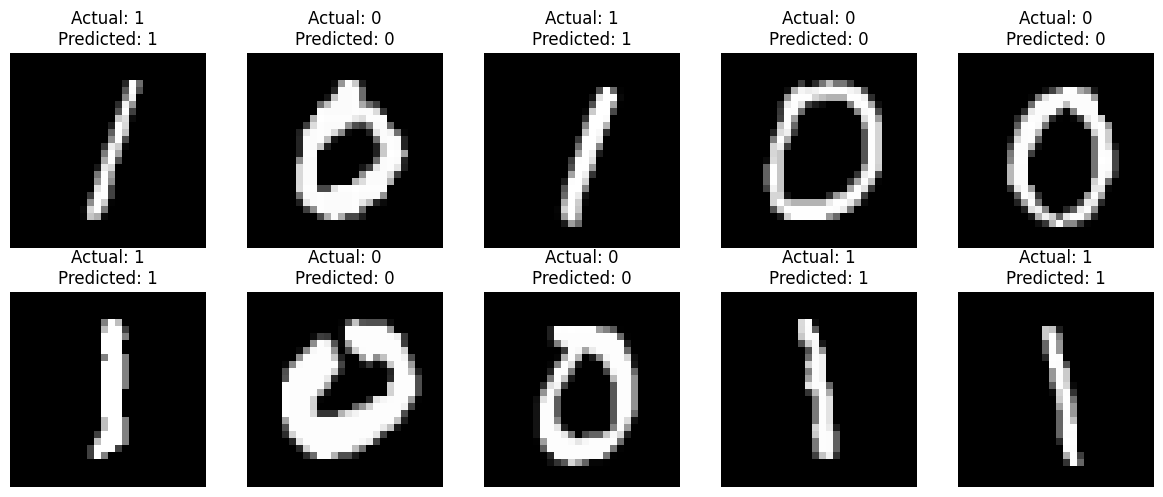

In [ ]:
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(f"Actual: {y_test[i]}\nPredicted: {y_pred[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

##  Generative Model – Autoencoder

An Autoencoder is a neural network that learns a compressed representation of the input images.

It consists of an encoder and a decoder. The encoder compresses the image information, while the decoder reconstructs the image.

Unlike the discriminative model, the Autoencoder learns the patterns and structure present in the digit images rather than simply predicting their labels.


In [ ]:
# Flatten the images for the Autoencoder
x_train_auto = x_train.reshape((len(x_train), 784))
x_test_auto = x_test.reshape((len(x_test), 784))

print(x_train_auto.shape)
print(x_test_auto.shape)

(12665, 784)
(2115, 784)


In [ ]:
# Size of compressed representation
encoding_dim = 32

# Input layer
input_img = Input(shape=(784,))

# Encoder
encoded = Dense(128, activation="relu")(input_img)
encoded = Dense(encoding_dim, activation="relu")(encoded)

# Decoder
decoded = Dense(128, activation="relu")(encoded)
decoded = Dense(784, activation="sigmoid")(decoded)

# Create Autoencoder model
autoencoder = Model(input_img, decoded)

autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = autoencoder.fit(
    x_train_auto,
    x_train_auto,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_auto, x_test_auto)
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.3523 - val_loss: 0.1807
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1596 - val_loss: 0.1380
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.1323 - val_loss: 0.1234
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.1185 - val_loss: 0.1097
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.1078 - val_loss: 0.1020
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1009 - val_loss: 0.0962
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0952 - val_loss: 0.0911
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0910 - val_loss: 0.0881
Epoch 9/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0884 - val_loss: 0.0858
Epoch 10/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0862 - val_loss: 0.0839


### Generated / Reconstructed Digit Images

The trained Autoencoder is used to reconstruct digit images. These reconstructed images show the patterns learned by the generative model.

In [ ]:
# Generate reconstructed images
generated_images = autoencoder.predict(x_test_auto)

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


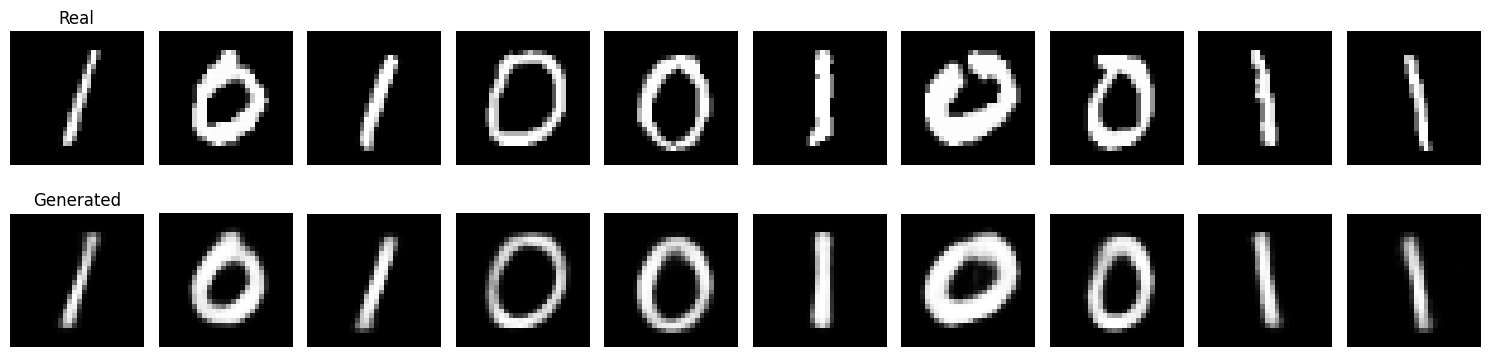

In [ ]:
n = 10

plt.figure(figsize=(15, 4))

for i in range(n):

    # Real images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_auto[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    if i == 0:
        ax.set_title("Real")

    # Generated images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(generated_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    if i == 0:
        ax.set_title("Generated")

plt.tight_layout()
plt.show()

## Generating New Digit Examples

The Autoencoder can also be used to create new digit-like images by generating random values in the learned latent space and passing them through the decoder.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


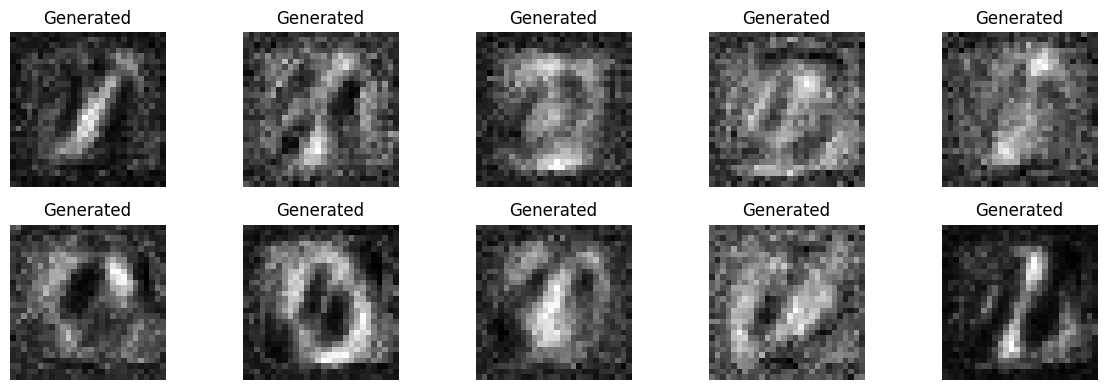

In [ ]:
# Create a separate decoder using the trained Autoencoder
decoder_input = Input(shape=(encoding_dim,))
decoder_layer1 = autoencoder.layers[-2](decoder_input)
decoder_output = autoencoder.layers[-1](decoder_layer1)

decoder = Model(decoder_input, decoder_output)

# Generate random latent representations
random_latent = np.random.normal(
    size=(10, encoding_dim)
)

# Generate new digit-like images
new_images = decoder.predict(random_latent)

# Display the newly generated images
plt.figure(figsize=(12, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(new_images[i].reshape(28, 28), cmap="gray")
    plt.title("Generated")
    plt.axis("off")

plt.tight_layout()
plt.show()

##  Visual Comparison

The following visualization compares the original MNIST digit, the prediction made by the discriminative model, and the reconstructed image produced by the Autoencoder.

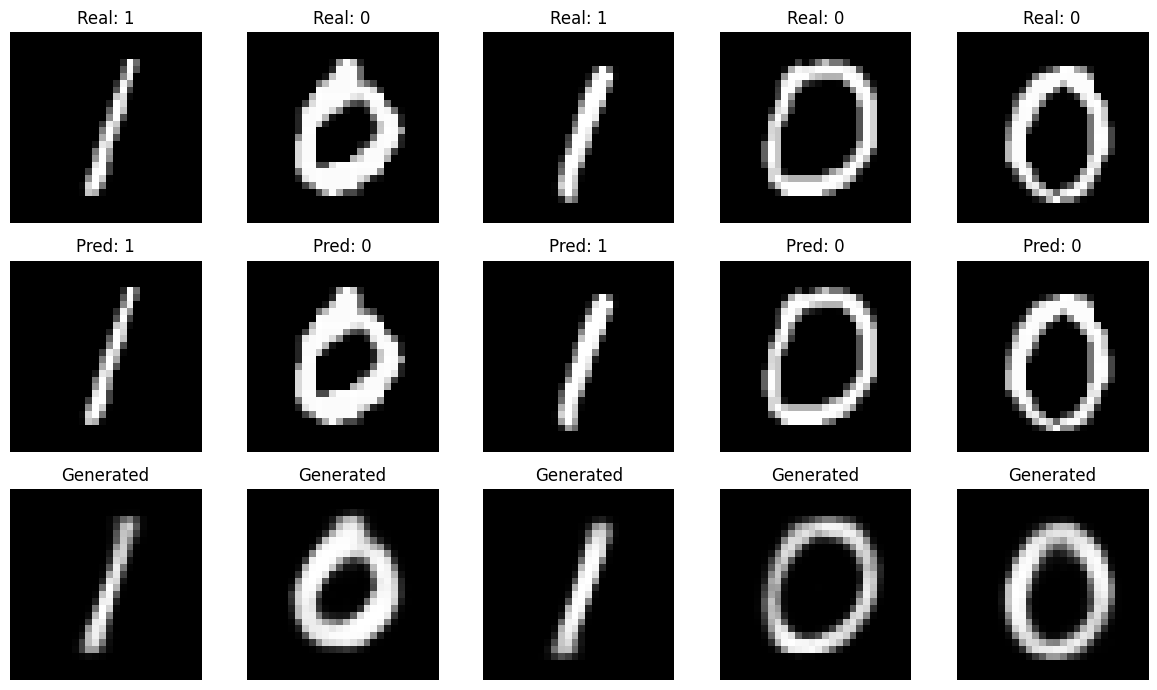

In [ ]:
n = 5

plt.figure(figsize=(12, 7))

for i in range(n):

    # Original image
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title("Real: " + str(y_test[i]))
    plt.axis("off")

    # Prediction
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test[i], cmap="gray")
    plt.title("Pred: " + str(y_pred[i]))
    plt.axis("off")

    # Generated image
    plt.subplot(3, n, i + 1 + (2 * n))
    plt.imshow(generated_images[i].reshape(28, 28), cmap="gray")
    plt.title("Generated")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Comparison of Discriminative and Generative Models

The Logistic Regression model is a discriminative model because it learns how to separate digit 0 from digit 1 using a decision boundary. Its main purpose is to correctly classify an input image.

The Autoencoder works differently. It learns the important patterns and features present in the digit images and uses this information to reconstruct the images.

Therefore, the discriminative model focuses on predicting the correct class, whereas the generative model focuses on learning the structure or distribution of the data.


## Written Reflection

The discriminative model learned to identify the difference between the digits 0 and 1 by looking at the patterns in the images. It then used these patterns to predict the correct digit for new images.

The generative model learned the main features and structure of the handwritten digits. It used what it learned to create or reconstruct similar digit images.

Overall, the discriminative model focuses on separating the classes and making predictions, while the generative model focuses on learning the patterns and features of the data.
